 ## Titanic Survival Project

## Problem Statement:
The Titanic Problem is based on the sinking of the ‘Unsinkable’ ship Titanic in early 1912. It gives you information about multiple people like their ages, sexes, sibling counts, embarkment points, and whether or not they survived the disaster. Based on these features, you have to predict if an arbitrary passenger on Titanic would survive the sinking or not. 

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [69]:
df=pd.read_csv('Data/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
df.shape

(891, 12)

#### Observation :
- **This Titanic Dataset contains 891 rows & 12 columns.**
- **Here our objective is to predict survival using classification algorithim for that Here our target variable is 'Survived'.**
- **We have 5 features with object datatypes & rest are with numerical features.**

### Data Integrity Check

In [71]:
df.duplicated().sum()

np.int64(0)

- **Missing Value check**

In [72]:
missing_values = df.isnull().sum().sort_values(ascending = False)
percentage_missing_values =(missing_values/len(df))*100
print(pd.concat([missing_values, percentage_missing_values], axis =1, keys =['Missing Values', '% Missing data']))

             Missing Values  % Missing data
Cabin                   687       77.104377
Age                     177       19.865320
Embarked                  2        0.224467
PassengerId               0        0.000000
Name                      0        0.000000
Pclass                    0        0.000000
Survived                  0        0.000000
Sex                       0        0.000000
Parch                     0        0.000000
SibSp                     0        0.000000
Fare                      0        0.000000
Ticket                    0        0.000000


### Observation :
- **Column 'Age', 'Embarked', and 'Cabin' have null values.**
- **19.86% of 'Age' data is null value,0.22% of 'Embarked' is null value, while 77.10% 'Cabin' data is null value.**
- **Dropping 'Cabin' since 77.10% of its values is missing and therefore it cannot contribute to building a good model for predicting the target variable values.**

In [73]:
df.drop(columns=['Cabin'],inplace = True)

## How Many Survived?

In [74]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

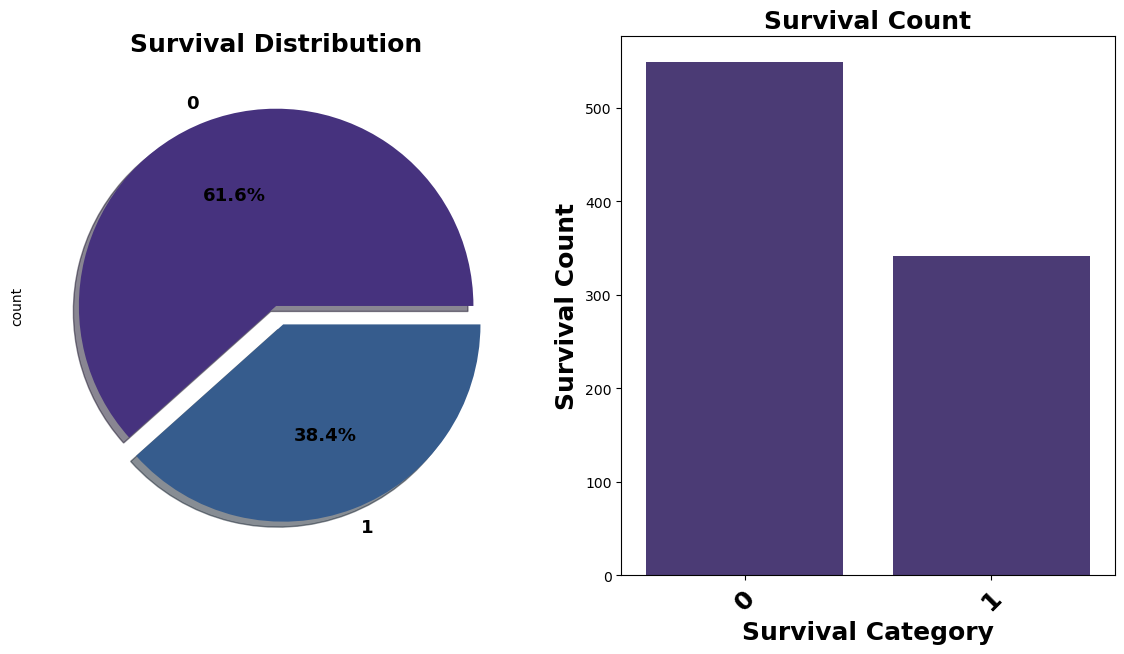

In [75]:
plt.figure(figsize=(14,7))
sns.set_palette('viridis')
plt.subplot(1,2,1)
df['Survived'].value_counts().plot.pie(explode=[0,0.1],textprops ={ 'fontsize':13,'fontweight' :'bold'},
                                       autopct='%2.1f%%',shadow=True)
plt.title('Survival Distribution',fontsize=18,fontweight ='bold')

plt.subplot(1,2,2)
sns.countplot(x='Survived',data=df)
plt.title('Survival Count',fontsize=18,fontweight ='bold')
plt.xlabel("Survival Category",fontsize=18,fontweight ='bold')
plt.ylabel("Survival Count", fontsize= 18, fontweight='bold')
plt.xticks(fontsize=18,fontweight ='bold',rotation=45)
plt.show()

#### Observation :-
> ***It is evident that not many passengers survived the accident.***
***
***Out of 891 passengers in vessel, only around 342 survived i.e only 38.4% of the passenger survived the crash.***

### Let Investiage Gender-wise Survival Rate of Passengers 

In [76]:
df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

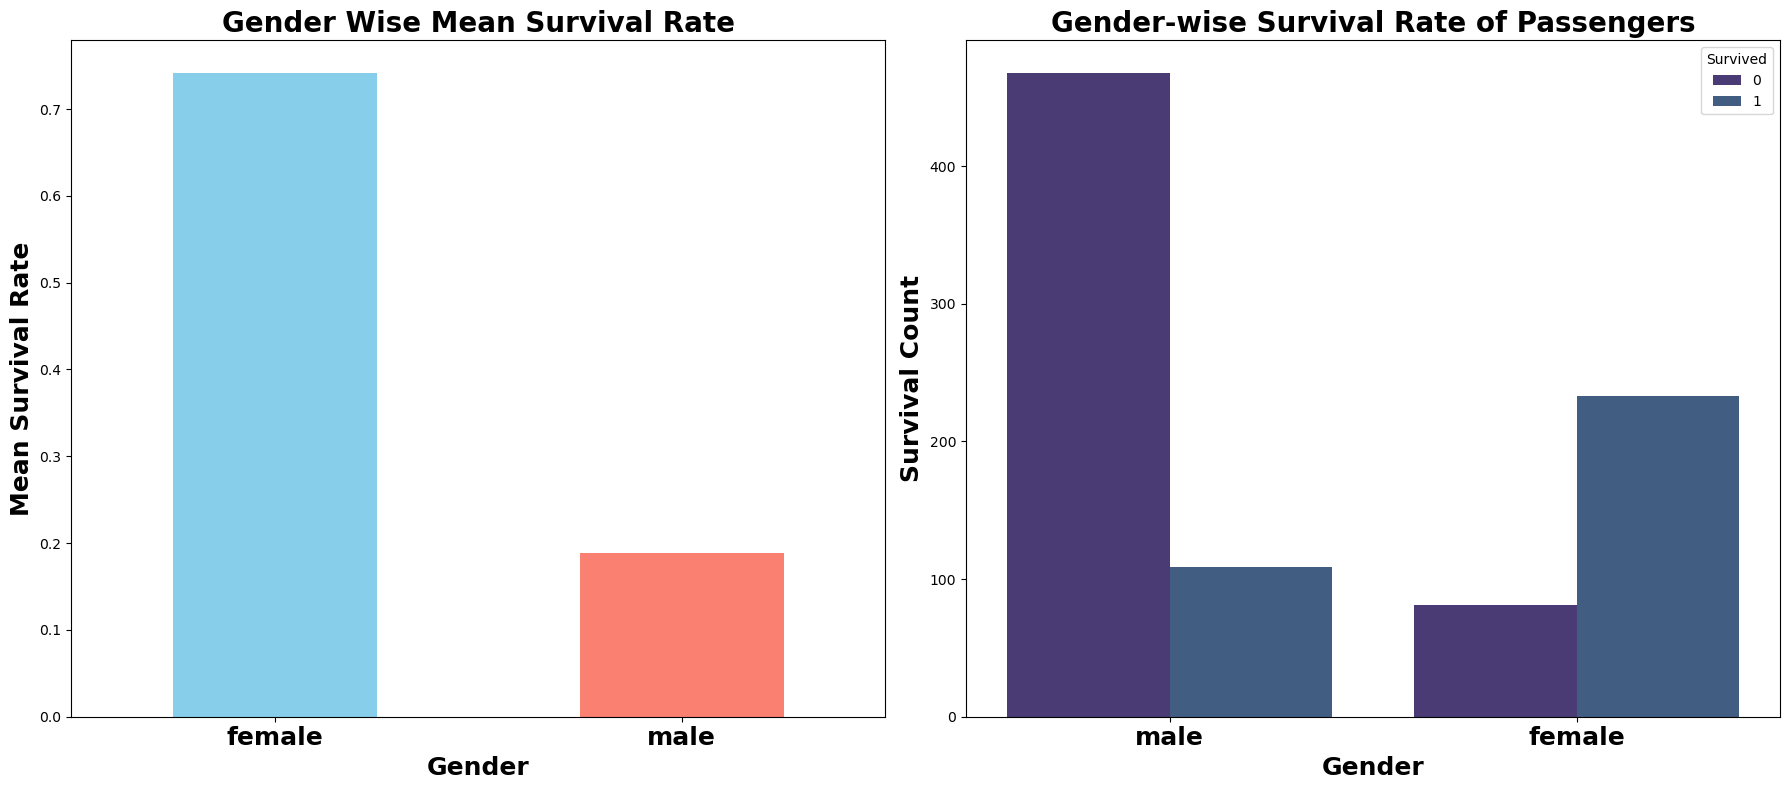

In [77]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
df.groupby('Sex')['Survived'].mean().plot.bar(color=['skyblue', 'salmon'])
plt.xticks(fontsize=18, fontweight='bold', rotation=0)
plt.title('Gender Wise Mean Survival Rate', fontsize=20, fontweight='bold')
plt.xlabel("Gender", fontsize=18, fontweight='bold')
plt.ylabel("Mean Survival Rate", fontsize=18, fontweight='bold')


plt.subplot(1, 2, 2)

sns.countplot(data=df, x='Sex', hue='Survived') 
plt.title('Gender-wise Survival Rate of Passengers', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18, fontweight='bold')
plt.xlabel("Gender", fontsize=18, fontweight='bold')
plt.ylabel("Survival Count", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

> **This looks interesting.** 
***
***The number of men on the ship is lot more than the number of women. Still the number of women saved is almost twice the number of males saved.***
***The survival rates for a Woman on ship is around 75% while that for men in around 18-19%.***

### Exploration of Passengers Class Vs Survival

In [78]:
pd.crosstab(df.Pclass,df.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


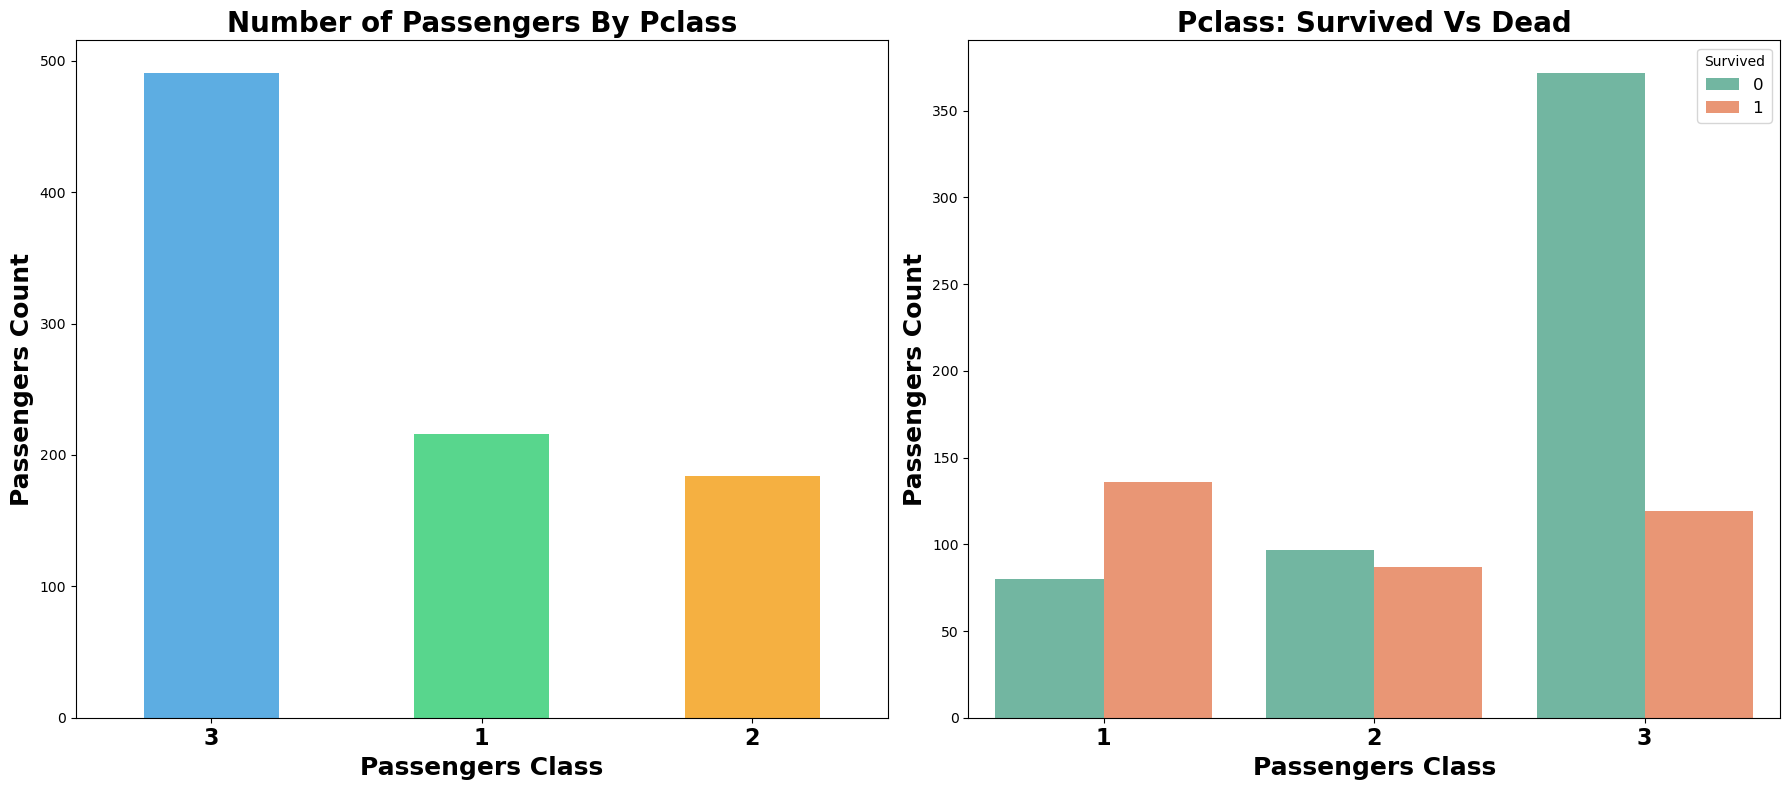

In [79]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)

df['Pclass'].value_counts().plot.bar(color=['#5DADE2','#58D68D','#F5B041'])

plt.title('Number of Passengers By Pclass', fontsize=20, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xlabel('Passengers Class', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold', rotation=0)


plt.subplot(1, 2, 2)

sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set2')

plt.title('Pclass: Survived Vs Dead', fontsize=20, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xlabel('Passengers Class', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.legend(title="Survived", fontsize=12)

plt.tight_layout()
plt.show()

#### Observation : -
> ***We can clearly, see that Passengers of <u>Pclass 1 were given a very high priority while rescue</u>. Even though the the number of passengers in Pclass 3 were a lot higher, <u>still the number of survival from Pclass 3 is very low</u>, somewhere around 25%.***
- **For Pclass 1 % Survived is around 63% while for pclass2 is around 48%. <u>In Conclusion money and status matters.</u> Such a materialistic world.**
***
### **Lets Dive in little bit more and check for other interesting observations. Lets check survival rate with Sex and Pclass Together.**

In [80]:
pd.crosstab([df.Sex,df.Survived],df.Pclass, margins= True).style.background_gradient(cmap='summer_r')

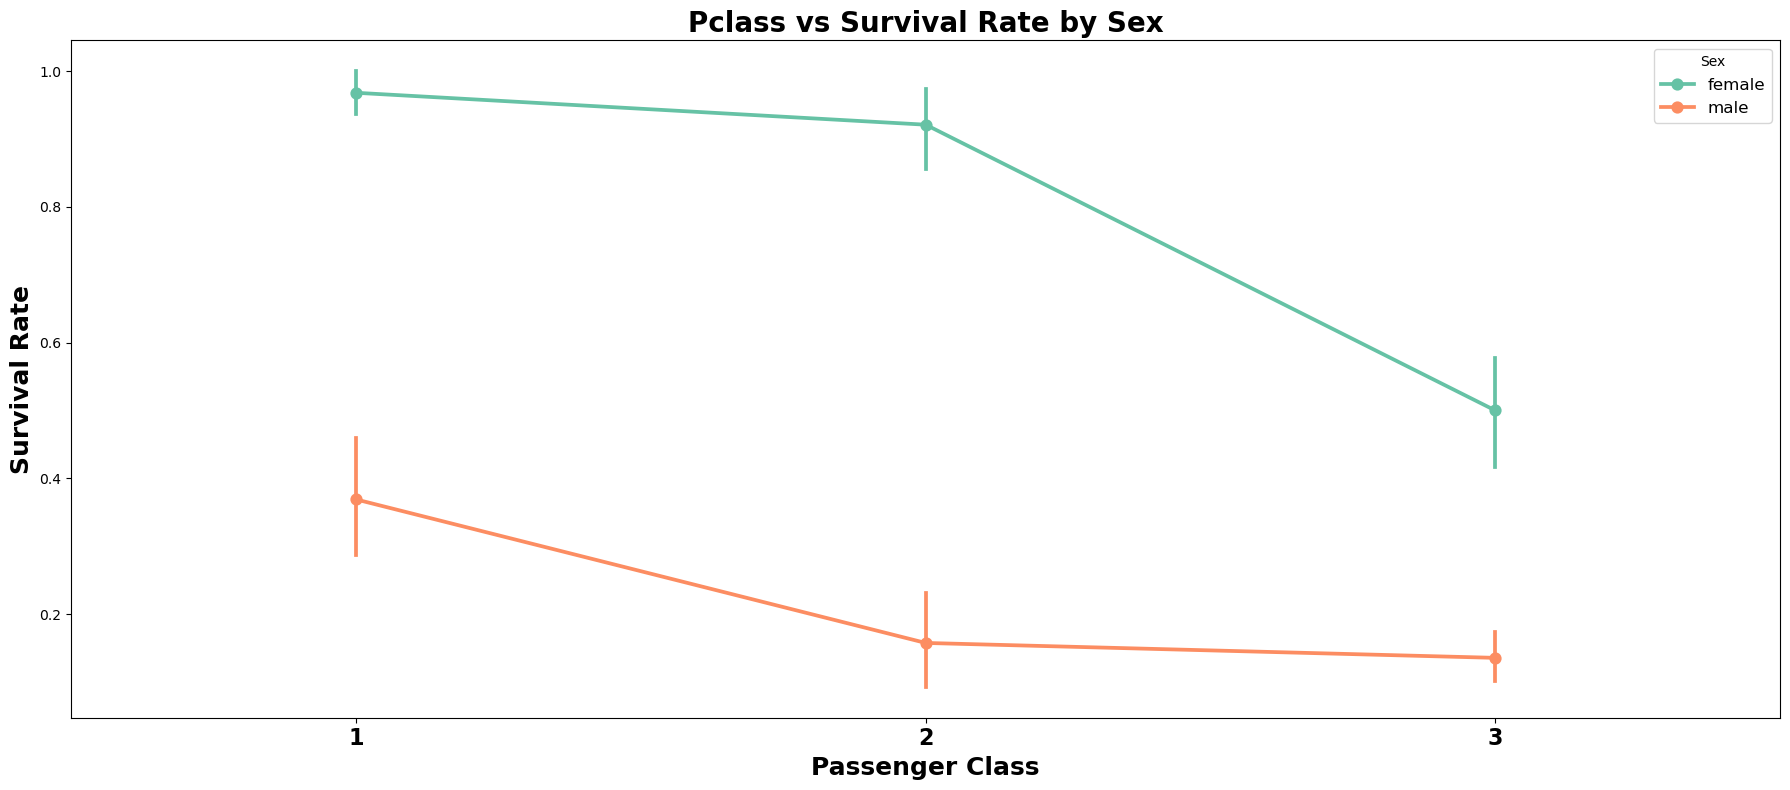

In [81]:
plt.figure(figsize=(18, 8))
sns.pointplot(data=df,x='Pclass', y='Survived',hue='Sex',palette='Set2')

plt.title('Pclass vs Survival Rate by Sex', fontsize=20, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=18, fontweight='bold')
plt.ylabel('Survival Rate', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.legend(title="Sex", fontsize=12)

plt.tight_layout()
plt.show()

#### Observation :-
- **Looking at the CrossTab and the Factorplot, we can easily infer that <u>survival for Women from Pclass 1 is about 95-96%, as only 3 out of 94 Women from Pclass1 died.</u>**
- **It is evident (from CrossTab and the Factorplot) that irrespective of pclass, women were given first priority while rescue. <u>Even Men from Pclass1 have a very low survival rate.</u>**

## Age 

In [82]:
print('Oldest Passenger was of:',df['Age'].max(),'Years')
print('Youngest Passenger was of:',df['Age'].min(),'Years')
print('Average Age on th ship :',df['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on th ship : 29.69911764705882 Years


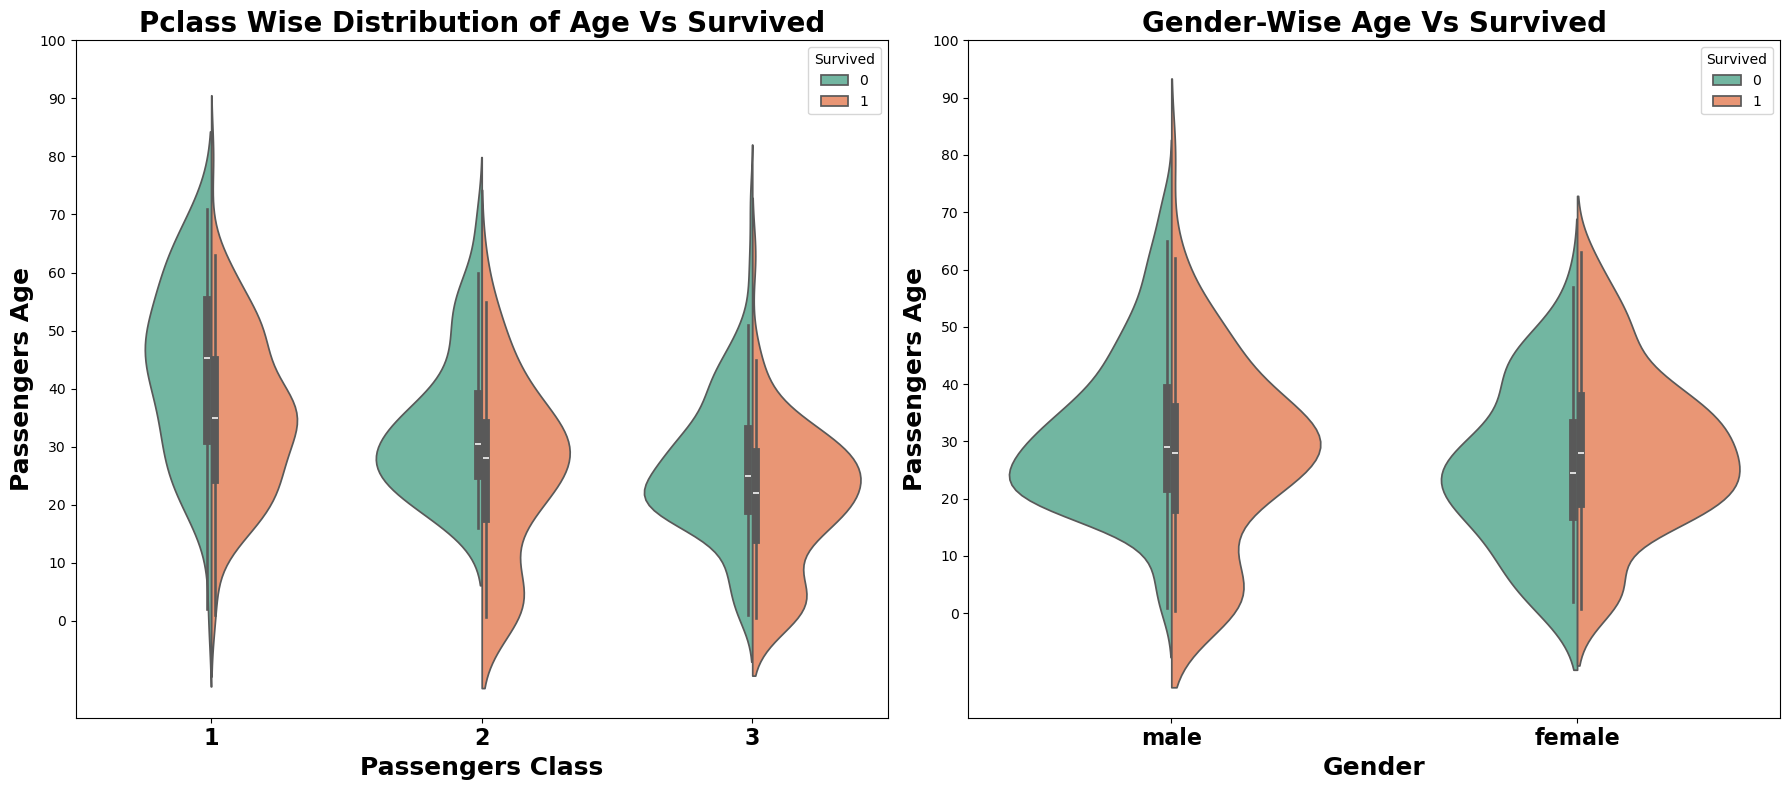

In [83]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)

sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', split=True, palette='Set2')

plt.title('Pclass Wise Distribution of Age Vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('Passengers Class', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Age', fontsize=18, fontweight='bold')
plt.yticks(range(0, 110, 10))
plt.xticks(fontsize=16, fontweight='bold')


plt.subplot(1, 2, 2)

sns.violinplot(data=df, x='Sex', y='Age', hue='Survived', split=True, palette='Set2')

plt.title('Gender-Wise Age Vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('Gender', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Age', fontsize=18, fontweight='bold')
plt.yticks(range(0, 110, 10))
plt.xticks(fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

- #### Observation :-
    - **The number of children increases with Pclass and the survival ratee for passenengers below age 10 looks to be good irrespective of the Pclass.**
    - **Survival chances for Passenegers aged 20-50 from Pclass 1 is high and even better for women.**
    - **For males, the survival chances decreases with increase in age.**

### Handling Missing Values in feature AGE

> **As we had seen eariler, the Age feature has 177 null values. to replace thses NaN values, we can assign them the mean age of the dataset.**
***
**We cannot simply Assign Mean Age for suppose of 29 year to 4 year old kid. So We must find another way to imputate mean age values.**

***Looking Upon the name Name Feature, we can see that <u>the names have as salutation like Mr or Mrs. Thus we can assign the mean values of Mr, Mrs etc. to the respective groups</u>.***

In [84]:
df['Initial']=0
for i in df:
    df['Initial']=df.Name.str.extract("([A-Za-z]+)\.") # Extract the Salutations with Regex

In [85]:
pd.crosstab(df.Initial,df.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [86]:
df['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],
                      ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

In [87]:
df.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

In [88]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr


### Filling NaN Ages

In [89]:
df.loc[(df.Age.isnull()) & (df.Initial == 'Mr'), 'Age'] = 32.73
df.loc[(df.Age.isnull()) & (df.Initial == 'Mrs'), 'Age'] = 35.98
df.loc[(df.Age.isnull()) & (df.Initial == 'Master'), 'Age'] = 4.57
df.loc[(df.Age.isnull()) & (df.Initial == 'Miss'), 'Age'] = 21.86
df.loc[(df.Age.isnull()) & (df.Initial == 'Other'), 'Age'] = 45.889

In [90]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
Initial        0
dtype: int64

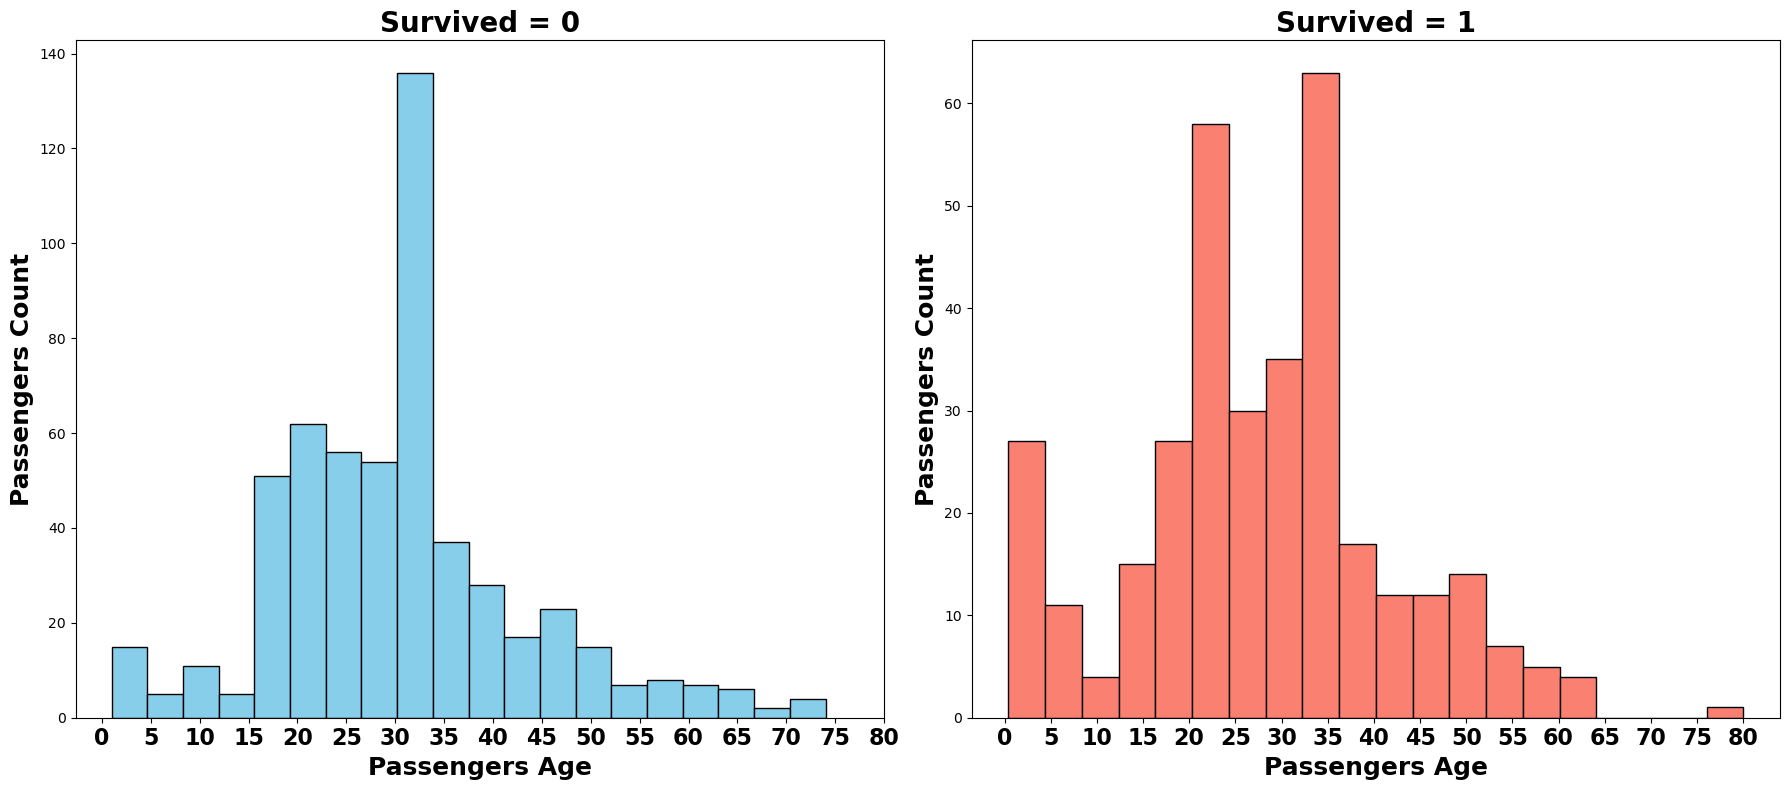

In [91]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)

df[df['Survived'] == 0]['Age'].plot.hist(bins=20,edgecolor='black',color='skyblue')

plt.title('Survived = 0', fontsize=20, fontweight='bold')
plt.xlabel('Passengers Age', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xticks(range(0, 85, 5), fontsize=16, fontweight='bold')

plt.subplot(1, 2, 2)

df[df['Survived'] == 1]['Age'].plot.hist(bins=20,edgecolor='black',color='salmon')

plt.title('Survived = 1', fontsize=20, fontweight='bold')
plt.xlabel('Passengers Age', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xticks(range(0, 85, 5), fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Observation :-
- **The Toddlers(age<5) were saved in large numbers. Possibliy, <u>Women and Child first policy employs while rescue operation employed.</u>**
- **The oldest Passenger was saved (80 years).**
- **Maximum number of deaths were in <u>age group of 30-40.</u>**

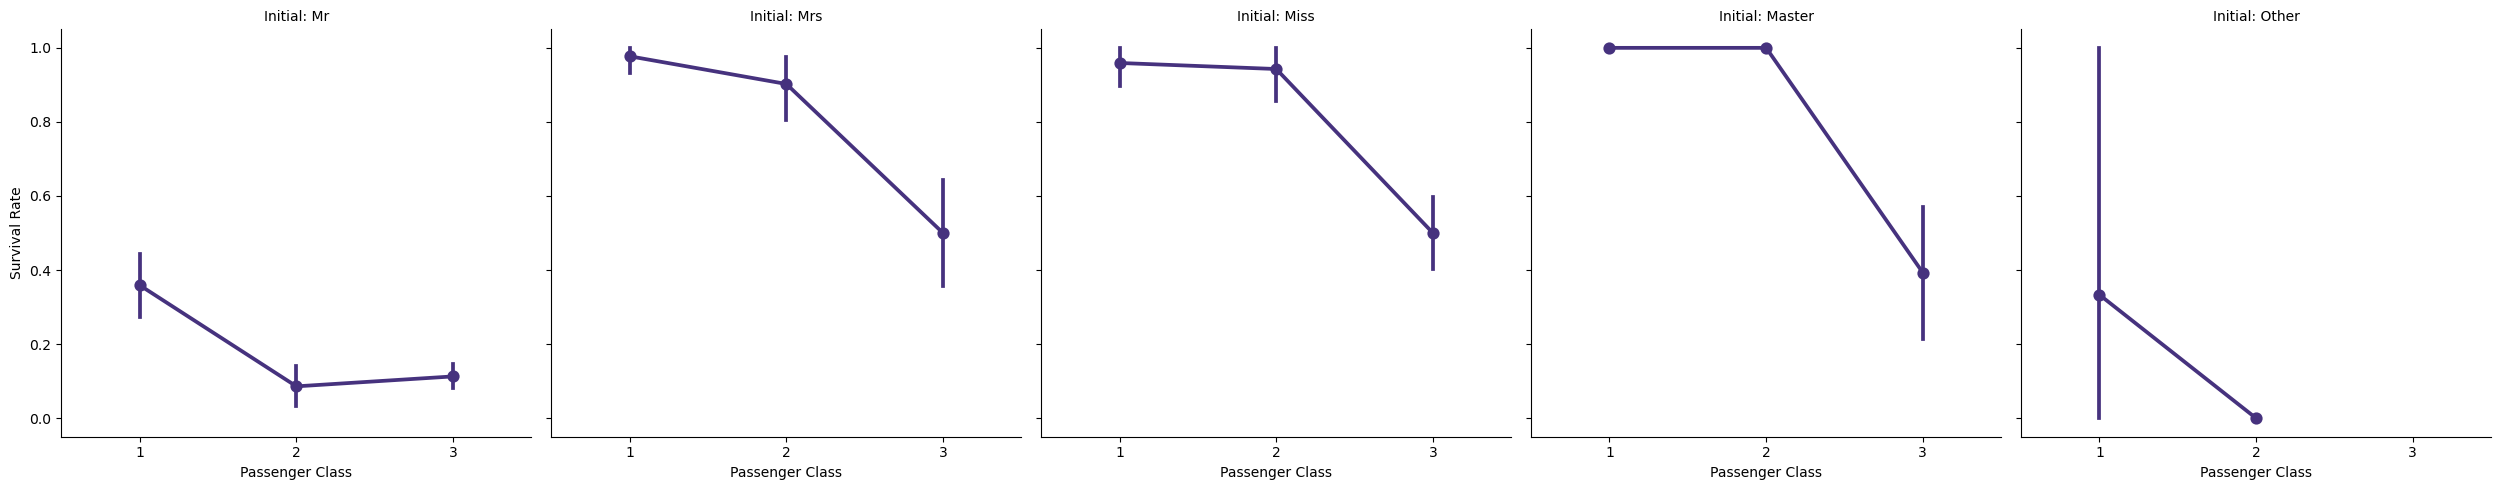

In [92]:
g = sns.catplot(data=df,x='Pclass',y='Survived',col='Initial',kind='point',height=5,aspect=1)

g.set_titles("Initial: {col_name}")
g.set_axis_labels("Passenger Class", "Survival Rate")

plt.tight_layout()
plt.show()

> <b> The women and child first policy thus holds true irrespective of the class.</b>

### Analysis Embarked vs Survival

In [93]:
pd.crosstab([df.Embarked,df.Pclass],[df.Sex,df.Survived],margins=True).style.background_gradient(cmap='summer_r')

### <b> Chances for Survival by Port of Embarkation </b>

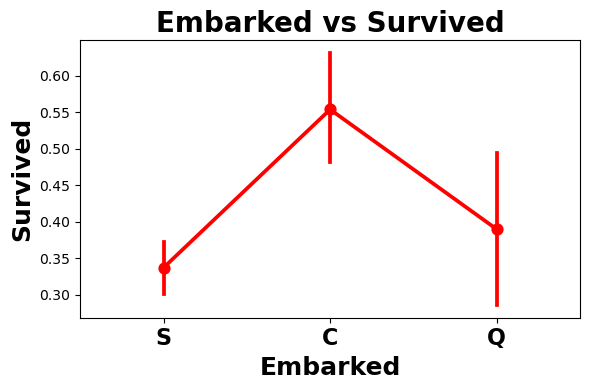

In [94]:
plt.figure(figsize=(6,4))

sns.pointplot(data=df,x='Embarked',y='Survived',color='red')

plt.title('Embarked vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('Embarked', fontsize=18, fontweight='bold')
plt.ylabel('Survived', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**The chances for survival for port C is highest around 0.55 while it is lowest for S.**

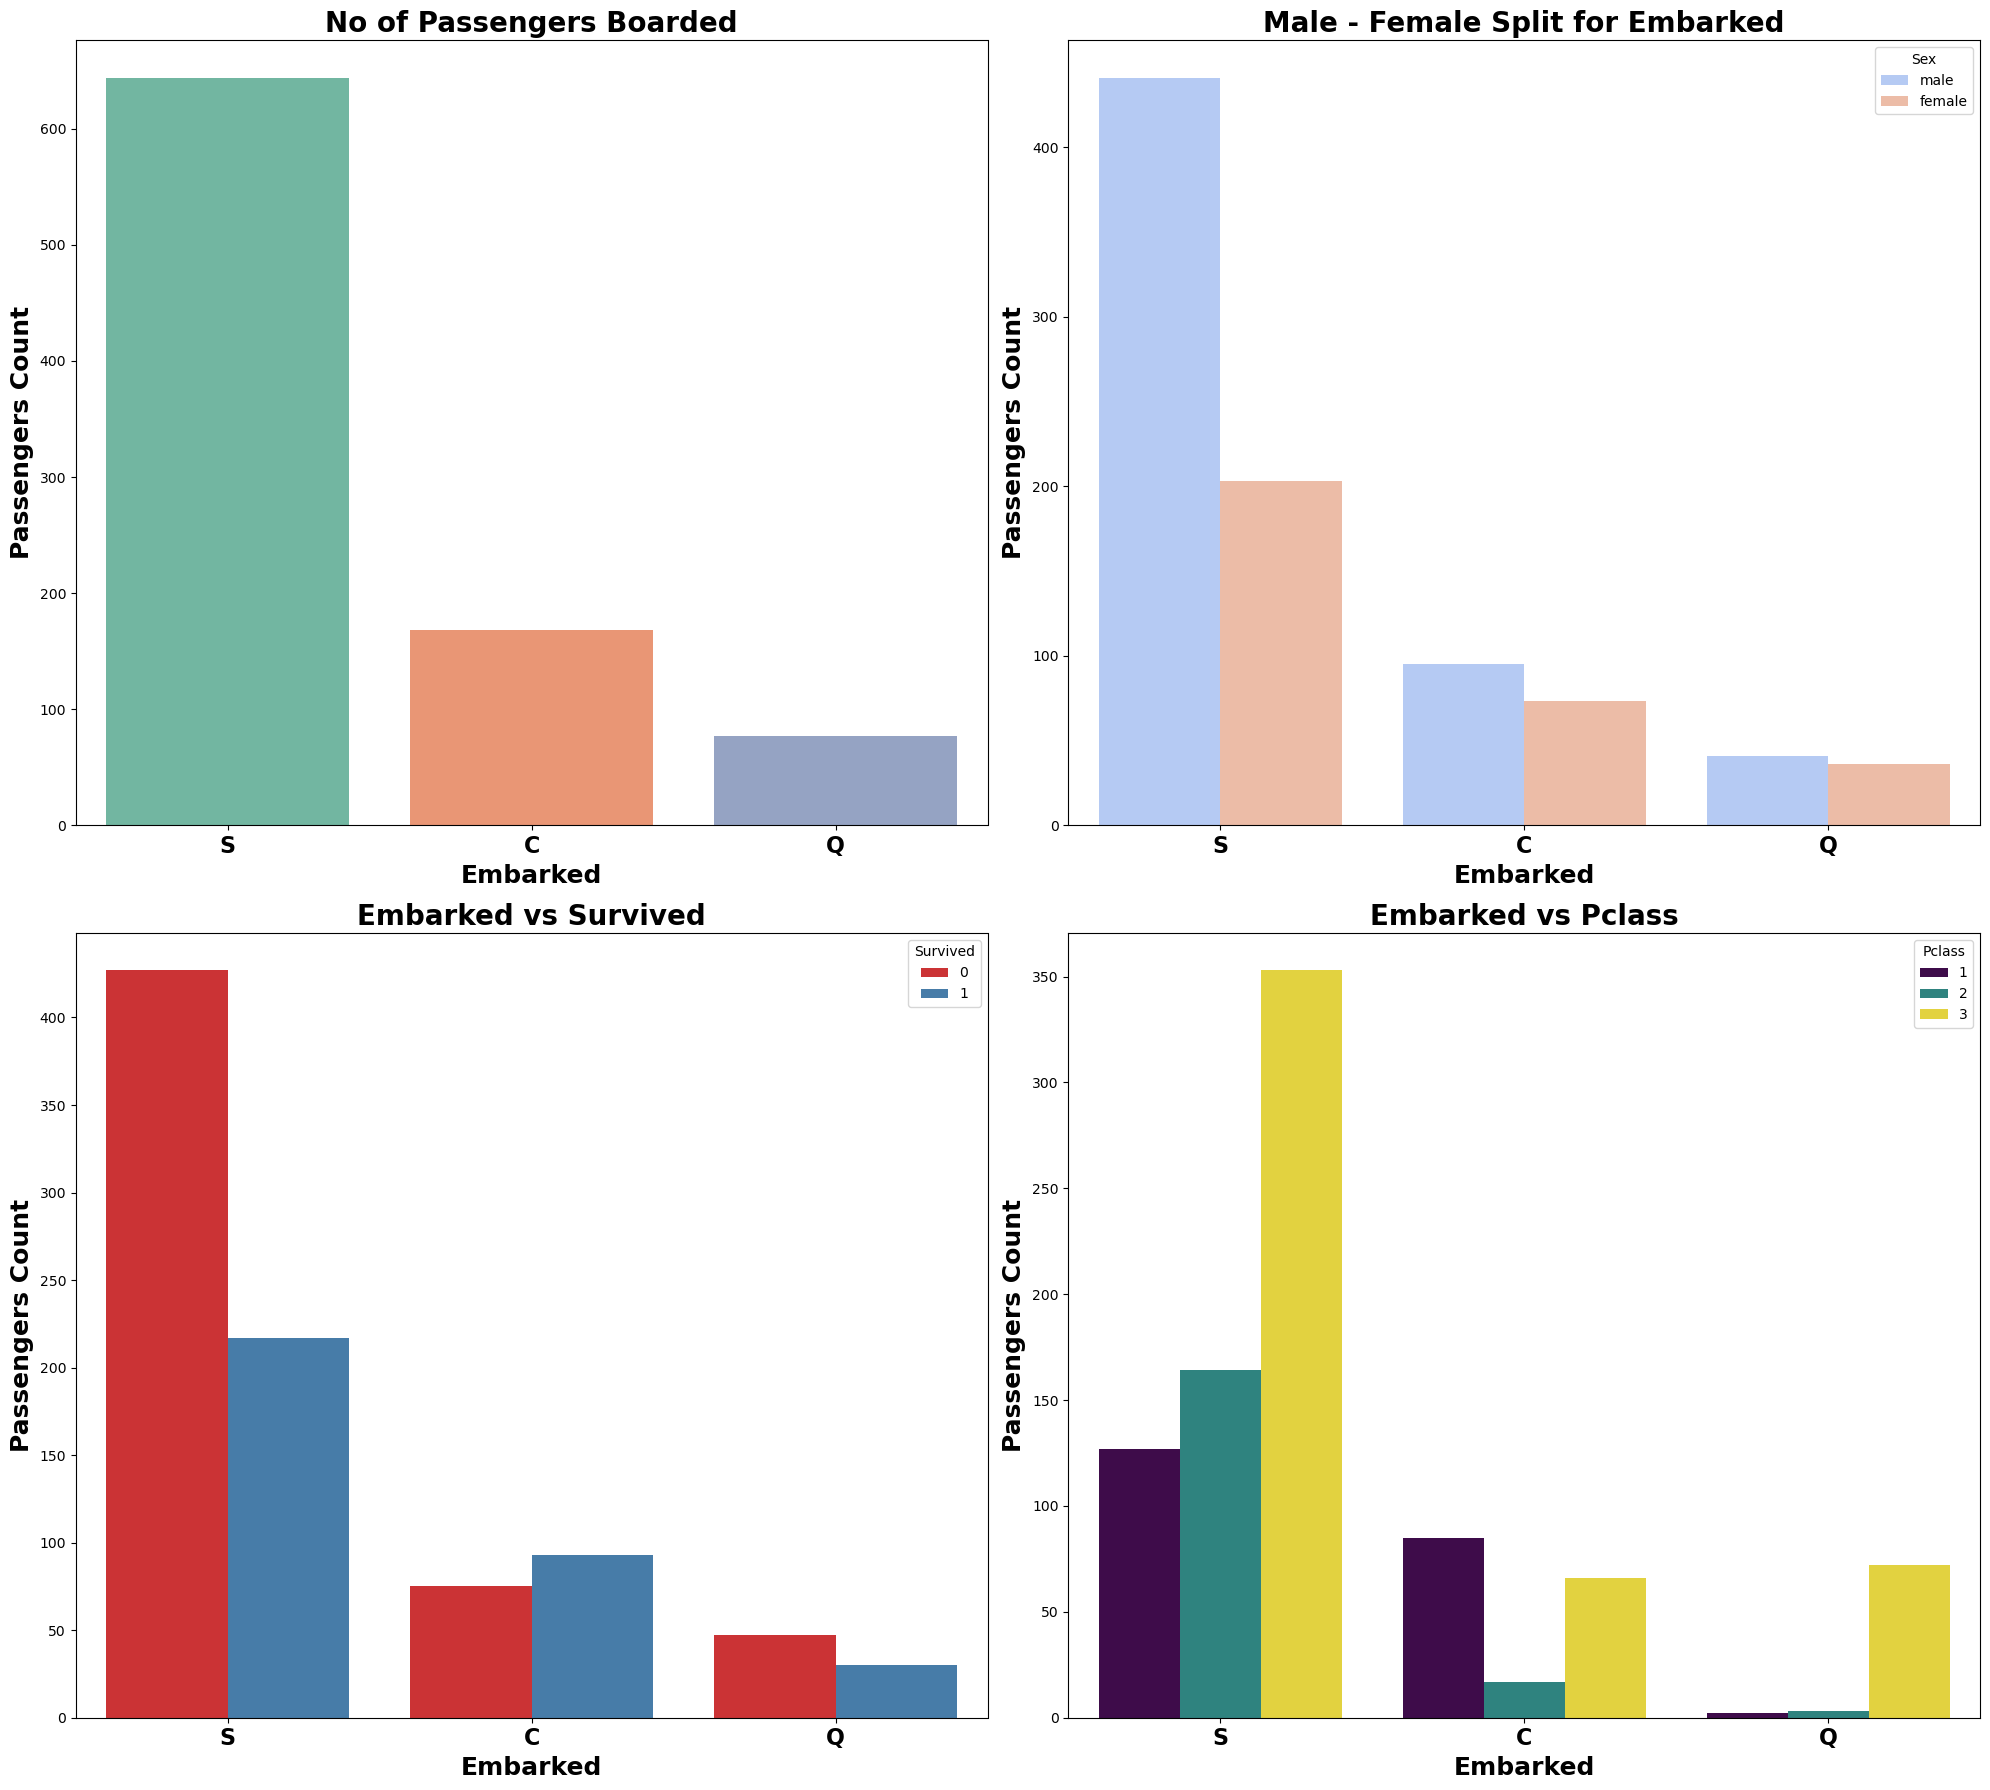

In [95]:
plt.figure(figsize=(20,18))

plt.subplot(2,2,1)

sns.countplot(data=df, x='Embarked', palette='Set2')

plt.title('No of Passengers Boarded', fontsize=20, fontweight='bold')
plt.xlabel('Embarked', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.subplot(2,2,2)

sns.countplot(data=df, x='Embarked', hue='Sex', palette='coolwarm')

plt.title('Male - Female Split for Embarked', fontsize=20, fontweight='bold')
plt.xlabel('Embarked', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.subplot(2,2,3)

sns.countplot(data=df, x='Embarked', hue='Survived', palette='Set1')

plt.title('Embarked vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('Embarked', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.subplot(2,2,4)

sns.countplot(data=df, x='Embarked', hue='Pclass', palette='viridis')

plt.title('Embarked vs Pclass', fontsize=20, fontweight='bold')
plt.xlabel('Embarked', fontsize=18, fontweight='bold')
plt.ylabel('Passengers Count', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Observation :-

   - **Maximum passengers boarded from S. <u>Majority of them being from Pclass 3.</u>**
   - **The Passengers from C look to be lucky as as good proportion of them survived.** The reason for this may be the rescue of all the Pclass 1 and Pclass 2 Passengers.
   - **<u>The Embark S looks to the port from where majority of the rich people.</u> Still the chances for survival is low here, that is because many passengers from Pclass 3 around 81% didn't survive.**
   - Port Q had almost 95% of the passengers were from Pclass 3.


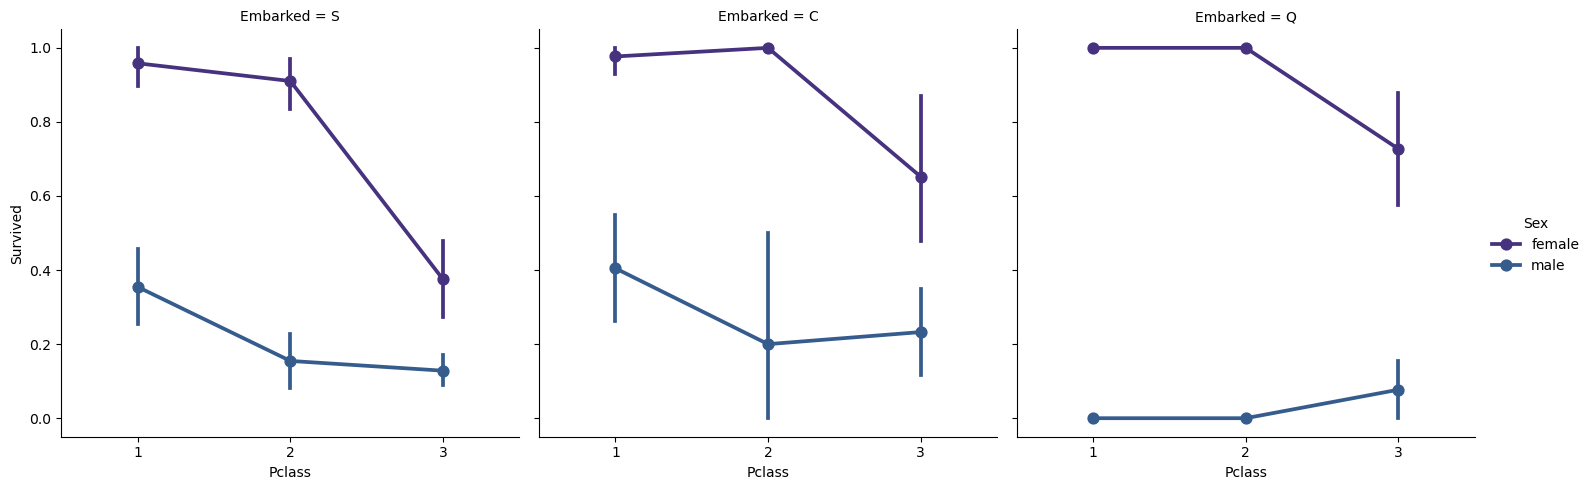

In [96]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', col='Embarked', data=df, kind='point')

plt.show()

### Observation :-
   - **The survival chances are almost 1 for women for Pclass 1 and Pclass 2 irrespective of the Pclass.**
   - **Port S looks to be very unlucky for Pclass 3 passengers** as the survival rate for both men and women is very low.
   - **Port Q looks to be unluckiest for Men, as almost all were from Pclass 3.**

### Filling Embarked NaN

As we saw that maximum passengers boarded from Port S, we replace NaN with S.

In [97]:
df['Embarked'].fillna('S', inplace=True)

In [98]:
df.Embarked.isnull().any()

np.False_

# SibSip vs Survived

In [99]:
pd.crosstab([df.SibSp],[df.Survived],margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
SibSp,,,
0,398,210,608
1,97,112,209
2,15,13,28
3,12,4,16
4,15,3,18
5,5,0,5
8,7,0,7
All,549,342,891


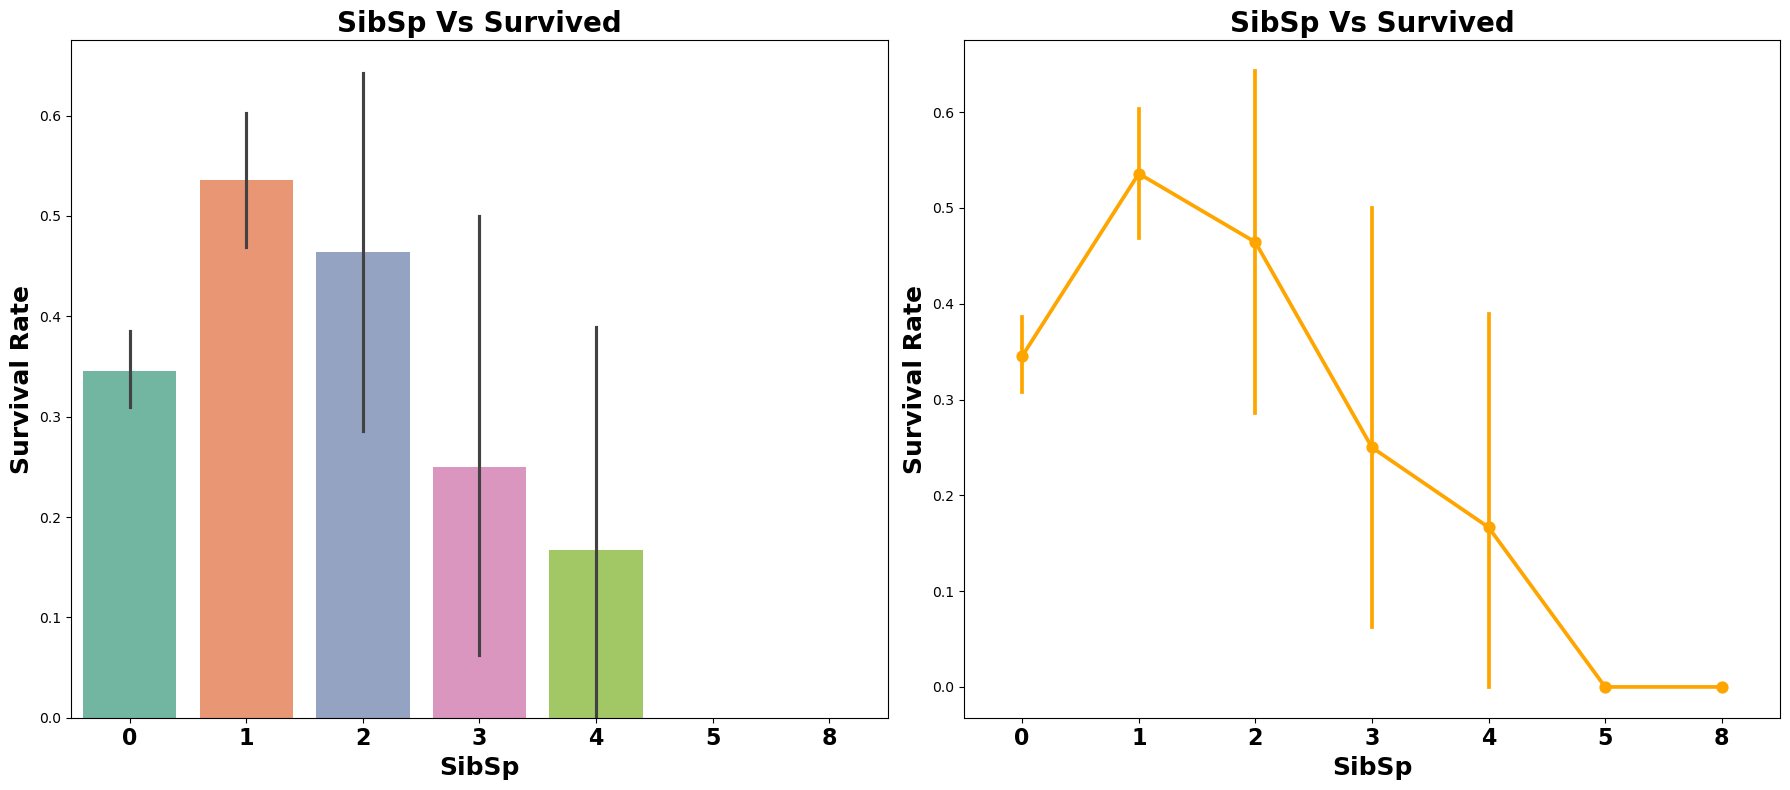

In [100]:
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)

sns.barplot(data=df, x='SibSp', y='Survived', palette='Set2')

plt.title('SibSp Vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('SibSp', fontsize=18, fontweight='bold')
plt.ylabel('Survival Rate', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.subplot(1,2,2)

sns.pointplot(data=df, x='SibSp', y='Survived', color='orange')

plt.title('SibSp Vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('SibSp', fontsize=18, fontweight='bold')
plt.ylabel('Survival Rate', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [101]:
pd.crosstab([df.SibSp],[df.Pclass],margins=True).style.background_gradient(cmap='summer_r')

Pclass,1,2,3,All
SibSp,,,,
0,137,120,351,608
1,71,55,83,209
2,5,8,15,28
3,3,1,12,16
4,0,0,18,18
5,0,0,5,5
8,0,0,7,7
All,216,184,491,891


### Observation :-
- The barplot and factor plot show that if as passenger is alone onboard with no siblings, **Passenger have 34.5% survival rate. The graph roughly decreases if the number of sibilings increase.** 
   
    <u>***Surprisingly the survival for families with 5-8 members is 0% . The reason may be Pclass ?***</u>
    
    
- <em> **The crosstab shows that person with SibSp>3 were all in Pclass. It is imminent that all the large families in Pclass 3 (>3) died.**</em>

## Parch Vs Survial

In [102]:
pd.crosstab([df.Parch],[df.Pclass],margins=True).style.background_gradient(cmap='summer_r')

Pclass,1,2,3,All
Parch,,,,
0,163,134,381,678
1,31,32,55,118
2,21,16,43,80
3,0,2,3,5
4,1,0,3,4
5,0,0,5,5
6,0,0,1,1
All,216,184,491,891


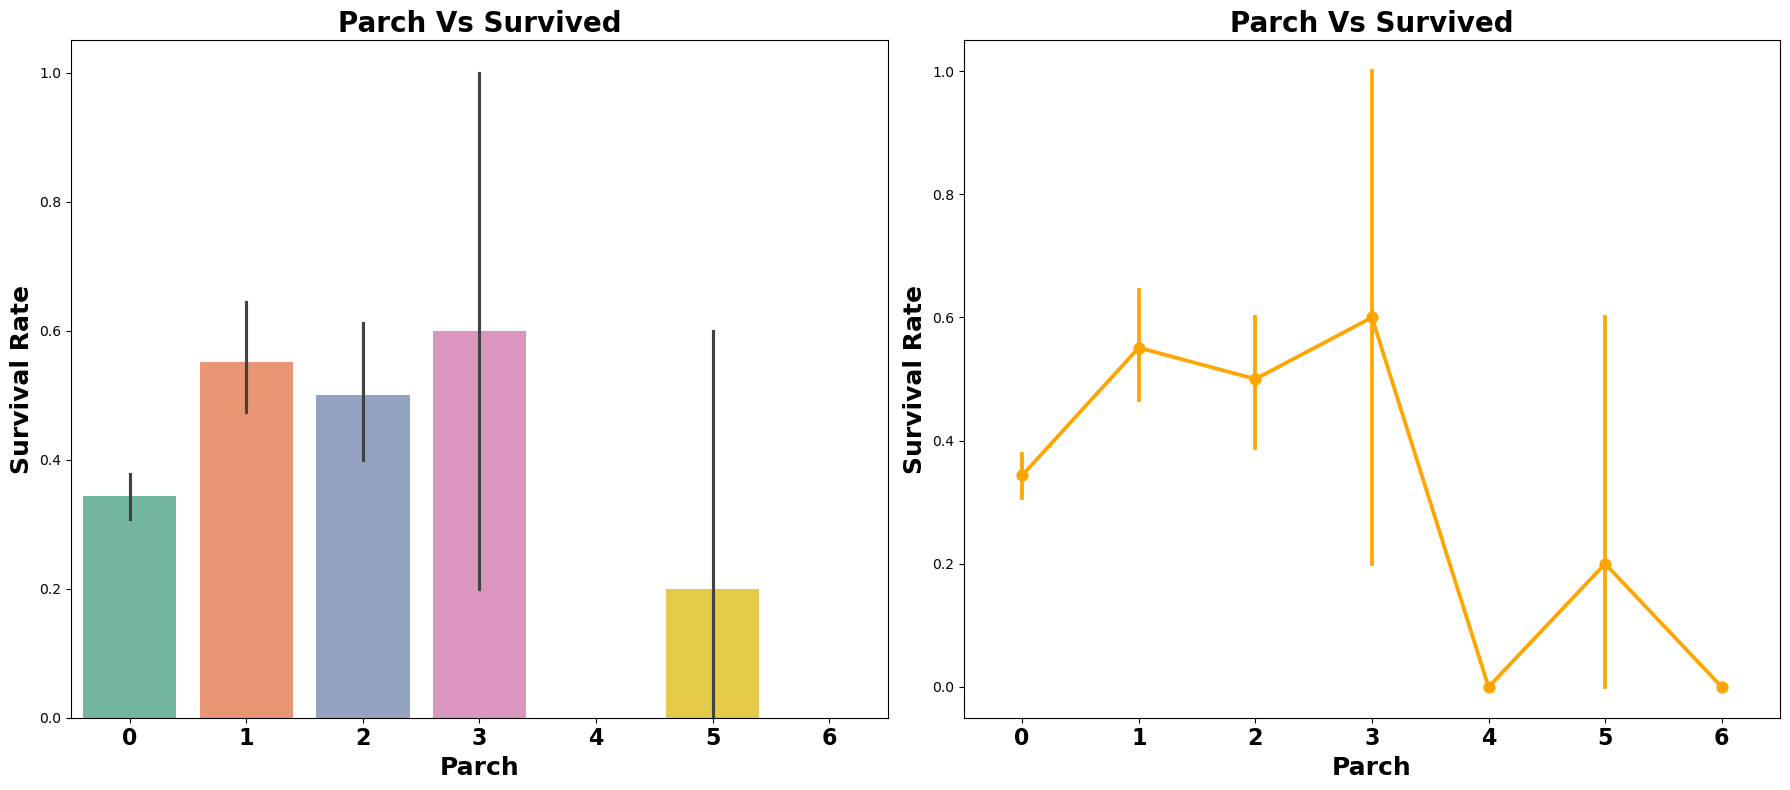

In [103]:
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)

sns.barplot(data=df, x='Parch', y='Survived', palette='Set2')

plt.title('Parch Vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('Parch', fontsize=18, fontweight='bold')
plt.ylabel('Survival Rate', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.subplot(1,2,2)

sns.pointplot(data=df, x='Parch', y='Survived', color='orange')

plt.title('Parch Vs Survived', fontsize=20, fontweight='bold')
plt.xlabel('Parch', fontsize=18, fontweight='bold')
plt.ylabel('Survival Rate', fontsize=18, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Observation :-
   - Here too the results are quite similar. ***Passengers with their parents onboard have greater chance of survival.*** it however reduces as the number goes up.
   - **The chances of survival is good for somebody who has 1-3 parents on the ship.**

## Fare Vs Survival

In [104]:
print('Highest Fare was :',df['Fare'].max())
print('Highest Fare was :',df['Fare'].min())
print('Average Fare was :',df['Fare'].mean())

Highest Fare was : 512.3292
Highest Fare was : 0.0
Average Fare was : 32.204207968574636


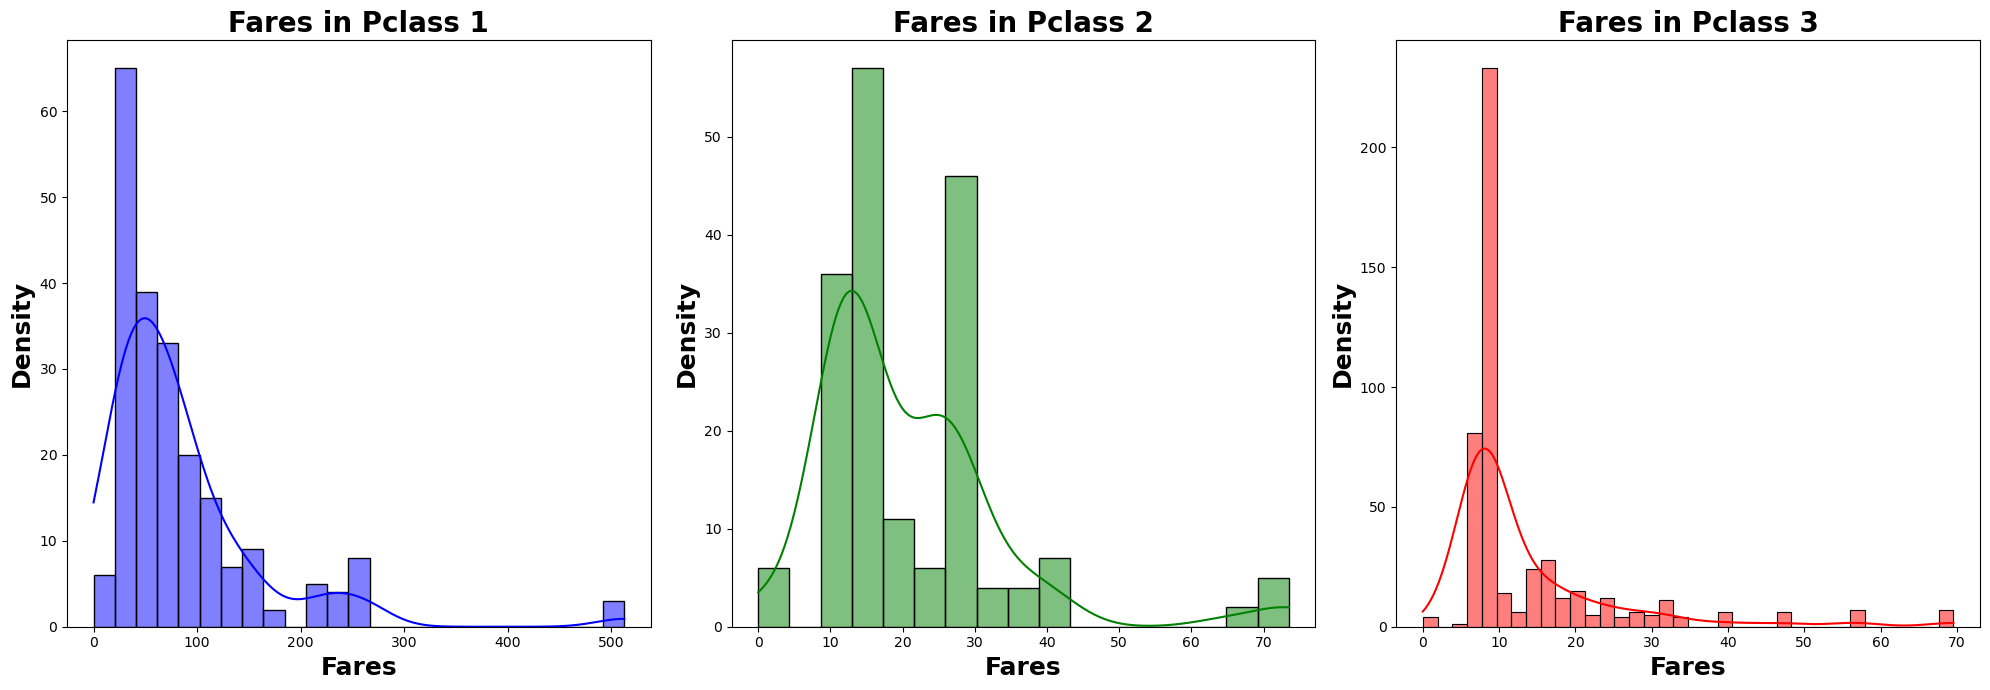

In [105]:
plt.figure(figsize=(20,7))

plt.subplot(1,3,1)

sns.histplot(df[df['Pclass']==1]['Fare'], kde=True, color='blue')

plt.title('Fares in Pclass 1', fontsize=20, fontweight='bold')
plt.xlabel('Fares', fontsize=18, fontweight='bold')
plt.ylabel('Density', fontsize=18, fontweight='bold')

plt.subplot(1,3,2)

sns.histplot(df[df['Pclass']==2]['Fare'], kde=True, color='green')

plt.title('Fares in Pclass 2', fontsize=20, fontweight='bold')
plt.xlabel('Fares', fontsize=18, fontweight='bold')
plt.ylabel('Density', fontsize=18, fontweight='bold')

plt.subplot(1,3,3)

sns.histplot(df[df['Pclass']==3]['Fare'], kde=True, color='red')

plt.title('Fares in Pclass 3', fontsize=20, fontweight='bold')
plt.xlabel('Fares', fontsize=18, fontweight='bold')
plt.ylabel('Density', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

- **There looks to be a large distribution in the fares of Passengers in Pclass1 and this distribution goes on decreasing as the standards reduces. As this is also Continous , we can convert into discrete values by using binning**

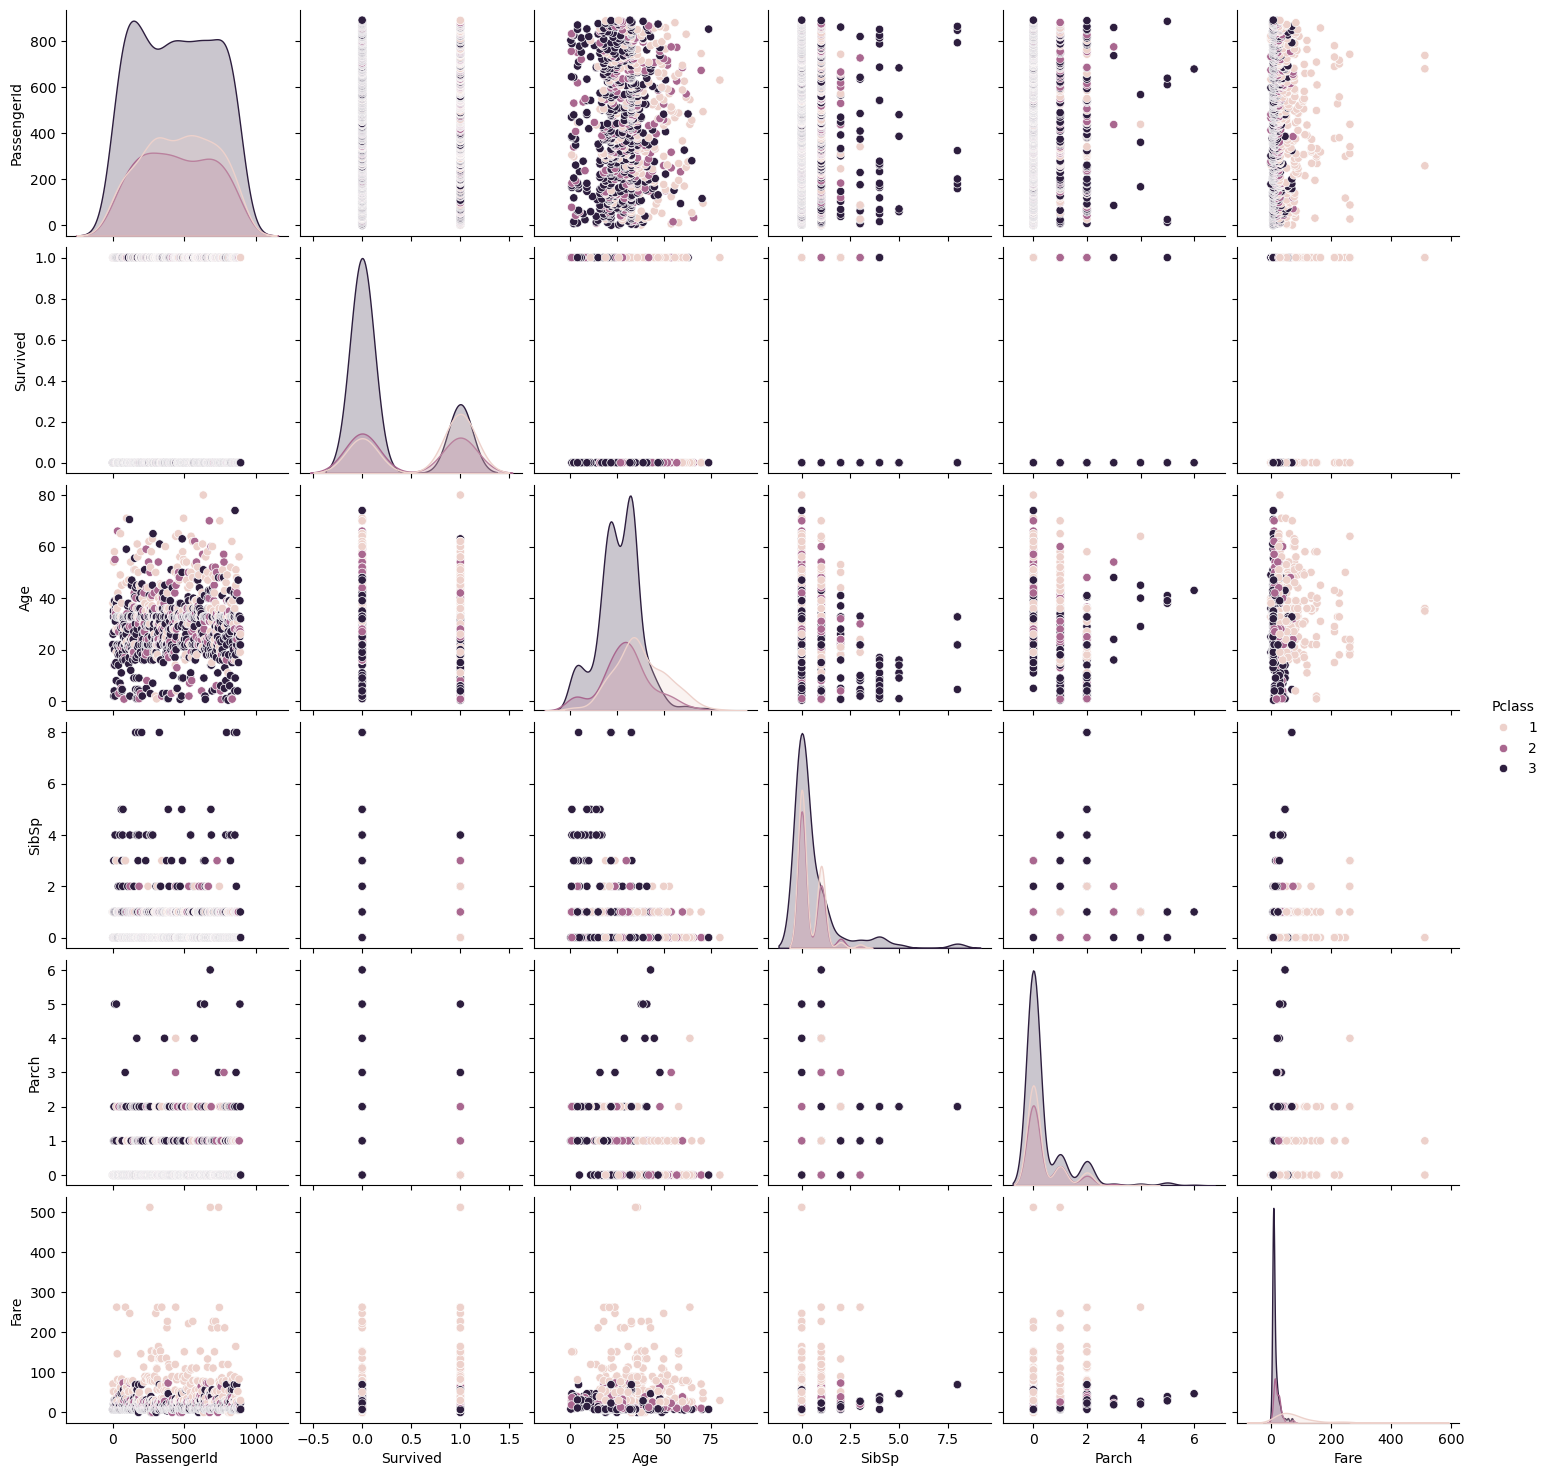

In [106]:
sns.pairplot(data=df, hue='Pclass')

plt.show()

###  Outliers Detection and Removal

In [107]:
# Droping unnecessary column for further investigation
df.drop(["PassengerId", "Name" , "Ticket" ],axis=1,inplace=True)

In [108]:
# As we have lot of Columns Lets sort Columns by their datatype
df.columns.to_series().groupby(df.dtypes).groups

{int64: ['Survived', 'Pclass', 'SibSp', 'Parch'], float64: ['Age', 'Fare'], object: ['Sex', 'Embarked', 'Initial']}

In [109]:
Numerical_features= ['Survived', 'Pclass', 'SibSp', 'Parch','Age', 'Fare']
Categorical_features = ['Sex', 'Embarked', 'Initial']

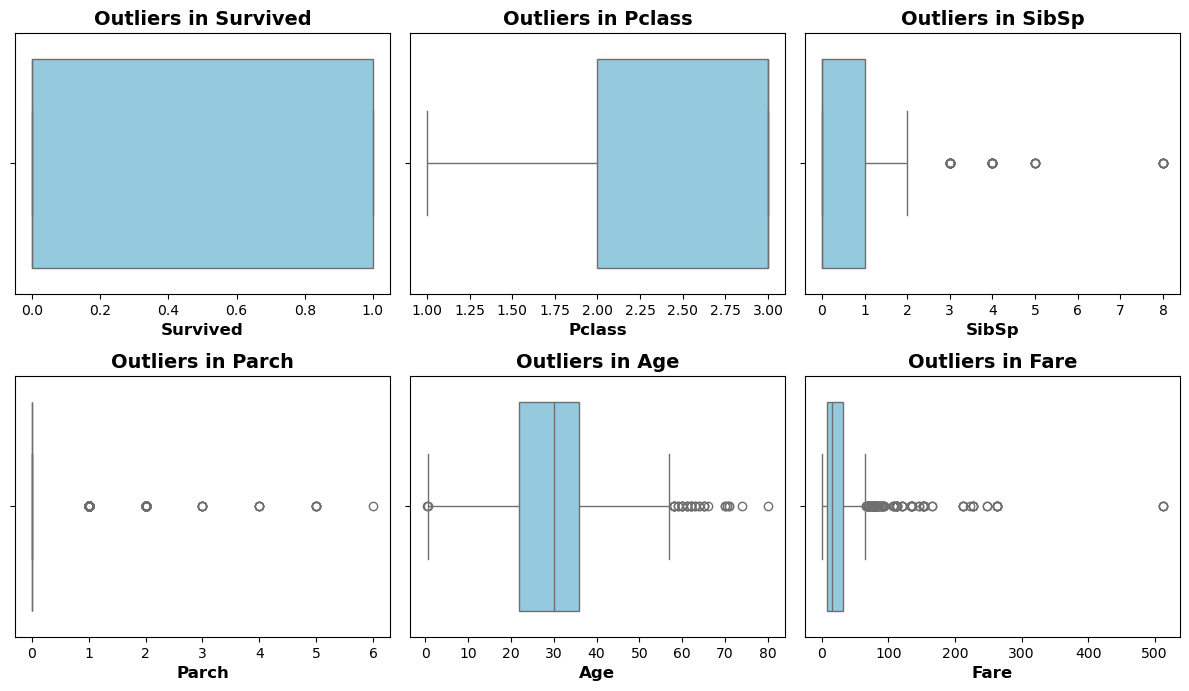

In [110]:
# Identifying outliers using boxplots
plt.figure(figsize=(12,10), facecolor='white')

plotnumber = 1

for feature in Numerical_features:
    if plotnumber <= 9:
        plt.subplot(3,3,plotnumber)
        
        sns.boxplot(x=df[feature], color='skyblue')
        
        plt.title(f'Outliers in {feature}', fontsize=14, fontweight='bold')
        plt.xlabel(feature, fontsize=12, fontweight='bold')
        
        plotnumber += 1

plt.tight_layout()
plt.show()

- **We can see that continous features like age & fare contains outliers.**

In [111]:
# Outlier detection 

def detect_outliers(df,n,features):
    """
    Takes a dataframe df of features and returns a list of the indices
    corresponding to the observations containing more than n outliers according
    to the Tukey method.
    """
    outlier_indices = []
    
    # iterate over features(columns)
    for col in features:
        # 1st quartile (25%)
        Q1 = np.percentile(df[col], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[col],75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        
        # outlier step
        outlier_step = 1.5 * IQR
        
        # Determine a list of indices of outliers for feature col
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step )].index
        
        # append the found outlier indices for col to the list of outlier indices 
        outlier_indices.extend(outlier_list_col)
        
    # select observations containing more than 2 outliers
    outlier_indices = Counter(outlier_indices)        
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > n )
    
    return multiple_outliers   

In [112]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Initial
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


In [113]:
# detect outliers from Age, SibSp , Parch and Fare
from collections import Counter
Outliers_to_drop = detect_outliers(df,2,["Age","SibSp","Parch","Fare"])

In [114]:
# Drop outliers
df = df.drop(Outliers_to_drop, axis = 0).reset_index(drop=True)

In [115]:
df.shape

(876, 9)

In [116]:
# Filling missing value of Age 

## Fill Age with the median age of similar rows according to Pclass, Parch and SibSp
# Index of NaN age rows
index_NaN_age = list(df["Age"][df["Age"].isnull()].index)

for i in index_NaN_age :
    age_med = df["Age"].median()
    age_pred = df["Age"][((df['SibSp'] == df.iloc[i]["SibSp"]) & (df['Parch'] == df.iloc[i]["Parch"]) & (df['Pclass'] == df.iloc[i]["Pclass"]))].median()
    if not np.isnan(age_pred) :
        df['Age'].iloc[i] = age_pred
    else :
        df['Age'].iloc[i] = age_med

###  Encoding Categorical Features

In [117]:
# Using Label encoder for transforming Categorical data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in Categorical_features:
    df[i] = le.fit_transform(df[i])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Initial
0,0,3,1,22.0,1,0,7.2500,2,2
1,1,1,0,38.0,1,0,71.2833,0,3
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,3
4,0,3,1,35.0,0,0,8.0500,2,2


### Standard Scaler

In [118]:
# Splitting data in target and dependent feature
X = df.drop(['Survived'], axis =1)
Y = df['Survived']

In [119]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scale = scaler.fit_transform(X)

# **Machine Learning Model Building**

In [120]:
#Importing Machine learning Model library
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  Ridge
from sklearn.linear_model import  Lasso
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [121]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=67, test_size=.25)
print('Training feature matrix size:',X_train.shape)
print('Training target vector size:',Y_train.shape)
print('Test feature matrix size:',X_test.shape)
print('Test target vector size:',Y_test.shape)

Training feature matrix size: (657, 8)
Training target vector size: (657,)
Test feature matrix size: (219, 8)
Test target vector size: (219,)


In [122]:
lnr=LinearRegression()
lr=LogisticRegression()
rf = RandomForestRegressor()
dtc = DecisionTreeRegressor()
adb=AdaBoostRegressor()
knn=KNeighborsClassifier(n_neighbors = 18)

model = [lnr,lr,rf,knn,dtc,adb]

for m in model:
    m.fit(X_train,Y_train)
    m.score(X_train,Y_train)
    y_pred = m.predict(X_test)
    print('\n')                                        
    print('Error of ', m, ':')
    print('Mean absolute error :', mean_absolute_error(Y_test,y_pred))
    print('Mean squared error :', mean_squared_error(Y_test,y_pred))
    print('Root Mean Squared Error:', np.sqrt(mean_squared_error(Y_test,y_pred)))
    print('\n')

    print('R2 Score :')
    print(r2_score(Y_test,y_pred)) 
    print('='*50)



Error of  LinearRegression() :
Mean absolute error : 0.2759631789423892
Mean squared error : 0.12596183709214193
Root Mean Squared Error: 0.35491102700837845


R2 Score :
0.4441244323908522


Error of  LogisticRegression() :
Mean absolute error : 0.2054794520547945
Mean squared error : 0.2054794520547945
Root Mean Squared Error: 0.45329841391162456


R2 Score :
0.09320942215679073


Error of  RandomForestRegressor() :
Mean absolute error : 0.21988457973369335
Mean squared error : 0.12867151815542224
Root Mean Squared Error: 0.35870812390496853


R2 Score :
0.4321664812060907


Error of  KNeighborsClassifier(n_neighbors=18) :
Mean absolute error : 0.2602739726027397
Mean squared error : 0.2602739726027397
Root Mean Squared Error: 0.5101705328640019


R2 Score :
-0.14860139860139854


Error of  DecisionTreeRegressor() :
Mean absolute error : 0.22516489091831557
Mean squared error : 0.21829884803574737
Root Mean Squared Error: 0.46722462267708814


R2 Score :
0.03663681904283422


Error

## **Hyper Parameter Tuning : GridSearchCV**

In [123]:
from sklearn.model_selection import GridSearchCV

In [124]:
parameter = [{'fit_intercept': [True, False], #default: True
            'penalty': ['l1','l2'],
            'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'], #default: lbfgs
            'random_state': [69]
             }]

In [125]:
GCV = GridSearchCV(LogisticRegression(),parameter,verbose=5)
GCV.fit(X_train,Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END fit_intercept=True, penalty=l1, random_state=69, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END fit_intercept=True, penalty=l1, random_state=69, solver=newton-cg;, score=nan total time=   0.0s
[CV 3/5] END fit_intercept=True, penalty=l1, random_state=69, solver=newton-cg;, score=nan total time=   0.0s
[CV 4/5] END fit_intercept=True, penalty=l1, random_state=69, solver=newton-cg;, score=nan total time=   0.0s
[CV 5/5] END fit_intercept=True, penalty=l1, random_state=69, solver=newton-cg;, score=nan total time=   0.0s
[CV 1/5] END fit_intercept=True, penalty=l1, random_state=69, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END fit_intercept=True, penalty=l1, random_state=69, solver=lbfgs;, score=nan total time=   0.0s
[CV 3/5] END fit_intercept=True, penalty=l1, random_state=69, solver=lbfgs;, score=nan total time=   0.0s
[CV 4/5] END fit_intercept=True, penalty=l1, random_state=69, solver=l

GridSearchCV(estimator=LogisticRegression(),
             param_grid=[{'fit_intercept': [True, False],
                          'penalty': ['l1', 'l2'], 'random_state': [69],
                          'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                     'saga']}],
             verbose=5)

GridSearchCV(estimator=LogisticRegression(),
             param_grid=[{'fit_intercept': [True, False],
                          'penalty': ['l1', 'l2'], 'random_state': [69],
                          'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                     'saga']}],
             verbose=5)

In [126]:
GCV.best_params_

{'fit_intercept': True,
 'penalty': 'l2',
 'random_state': 69,
 'solver': 'newton-cg'}

#### Final Model

In [127]:
Final_mod = LogisticRegression(fit_intercept =True,penalty= "l2",solver='newton-cg',random_state= 69)
Final_mod.fit(X_train,Y_train)
y_pred=Final_mod.predict(X_test)
print('Final Random Forest Classifier Model')
print('Accuracy Score :\n', accuracy_score(Y_test, y_pred))
print('\n')
print('Confusion matrix of Random Forest Classifier :\n',confusion_matrix(Y_test, y_pred))
print('\n')
print('Classification Report of Random Forest Classifier\n',classification_report(Y_test, y_pred))

Final Random Forest Classifier Model
Accuracy Score :
 0.7945205479452054


Confusion matrix of Random Forest Classifier :
 [[122  21]
 [ 24  52]]


Classification Report of Random Forest Classifier
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       143
           1       0.71      0.68      0.70        76

    accuracy                           0.79       219
   macro avg       0.77      0.77      0.77       219
weighted avg       0.79      0.79      0.79       219



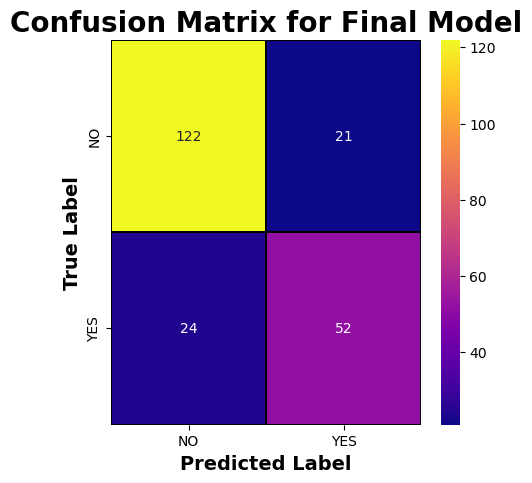

In [128]:
# Lets plot confusion matrix for  FinalModel
Matrix = confusion_matrix(Y_test, y_pred)

x_labels = ["NO","YES"]
y_labels = ["NO","YES"]

fig , ax = plt.subplots(figsize=(5,5))
sns.heatmap(Matrix, annot = True,linewidths=.2, linecolor="black", fmt = ".0f", ax=ax, 
            cmap="plasma", xticklabels = x_labels, yticklabels = y_labels)

plt.xlabel("Predicted Label",fontsize=14,fontweight='bold')
plt.ylabel("True Label",fontsize=14,fontweight='bold')
plt.title('Confusion Matrix for Final Model',fontsize=20,fontweight='bold')
plt.show()

## Saving model

In [129]:
import joblib
joblib.dump(Final_mod,'Titanic_Survival_Project.pkl')

['Titanic_Survival_Project.pkl']

## Predicting the Final Model

In [130]:
# Prediction
prediction = Final_mod.predict(X_test)

In [131]:
Actual = np.array(Y_test)
df_Pred = pd.DataFrame()
df_Pred["Predicted Values"] = prediction
df_Pred["Actual Values"] = Actual
df_Pred.head()

,Predicted Values,Actual Values
0,0,1
1,1,1
2,0,0
3,1,1
4,0,0
